some concepts:
    root node, internal node, leaf node, branch, depth
    entropy: 衡量标签数据的混乱程度 熵越大越混乱，纯净的节点熵为 0
    information gain = entropy - conditional entropy
        info gain 偏向多取值feature, 容易有过拟合的问题
    feature entropy: 衡量特征数据的混乱程度
    information gain rate = information gain / feature entropy
        相当于对info gain增加了惩罚系数，进行修正
        倾向于选择特征少的分支
    gini impurity: 从数据集里随机取两个样本，它们类别不同的概率。越纯净越接近 0，完全随机时最大
    gini index: 对gini impurity进行加权
decision tree:
    iterative dichotomiser 3: 每次选择info gain最大的特征作为分裂节点
    c4.5 tree: 每次选择info gain rate最大的特征作为分裂节点
    cart tree (classification and regression tree，是二叉树): 每次选择gini index最小的特征作为分裂节点 (cart分类树)
    

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
y pred: [1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1
 0 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0
 0 0 0 0 0 1 1 0 0 1 0 0 0

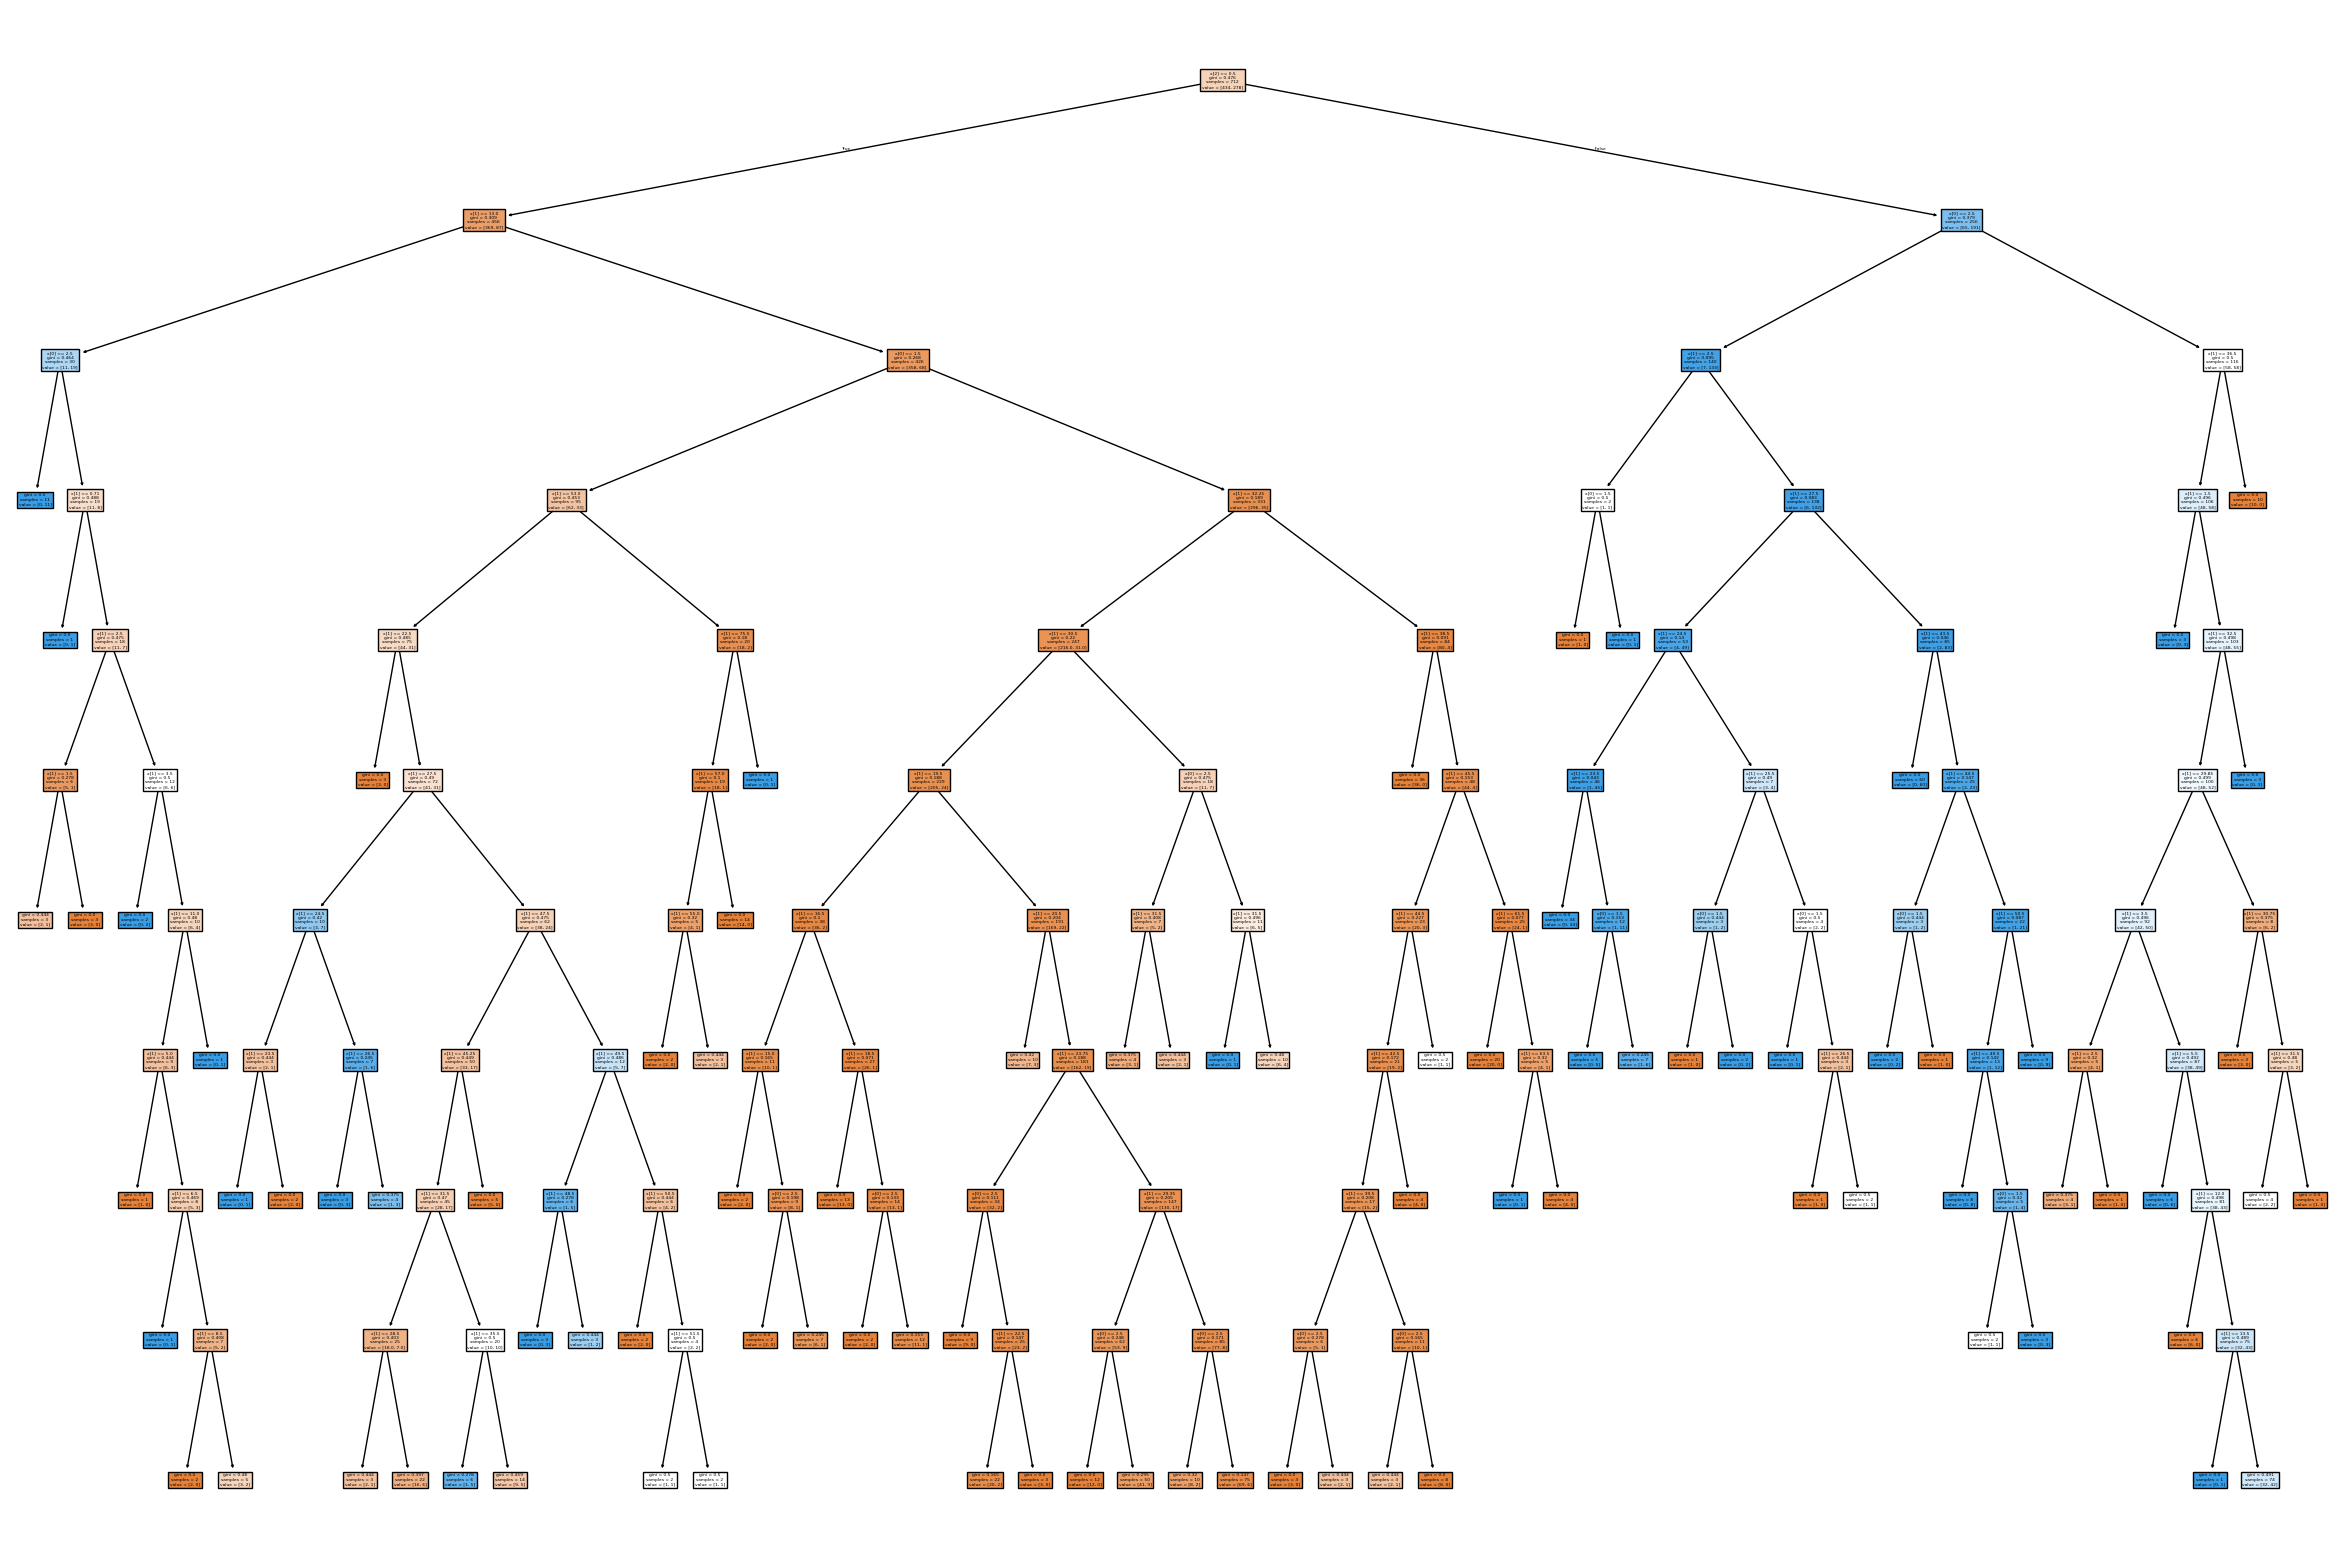

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

data = pd.read_csv('../data/train.csv')
data.info()

x = data[['Pclass', 'Sex', 'Age']]
y = data['Survived']

x = x.copy()
x['Age'] = x['Age'].fillna(x['Age'].mean())
x = pd.get_dummies(x, columns=['Sex'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

estimator = DecisionTreeClassifier(max_depth=10)
estimator.fit(x_train, y_train)

y_pred = estimator.predict(x_test)
print(f'y pred: {y_pred}')

print(f'Classification report:\n {classification_report(y_test, y_pred)}')


plt.figure(figsize=(30, 20))
plot_tree(estimator, filled=True, max_depth=10)
plt.savefig('../data/titanic_decision_tree.png')
plt.show()

cart回归树，每次选择 候选midpoints mse 最小的 作为分裂节点
    

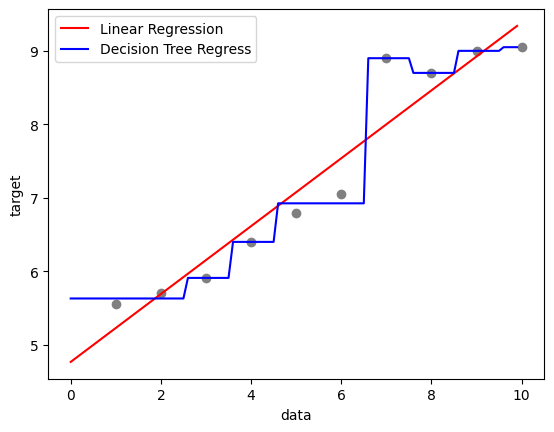

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

x_train = np.arange(1,11).reshape(-1, 1)
y_train = np.array([5.56, 5.7, 5.91, 6.4, 6.8, 7.05, 8.9, 8.7, 9, 9.05])

estimator1 = LinearRegression()
estimator2 = DecisionTreeRegressor(max_depth=3)

estimator1.fit(x_train, y_train)
estimator2.fit(x_train, y_train)

x_test = np.arange(0, 10, 0.1).reshape(-1, 1)
y_pred1 = estimator1.predict(x_test)
y_pred2 = estimator2.predict(x_test)

plt.scatter(x_train, y_train, c='gray')
plt.plot(x_test, y_pred1, c='red', label='Linear Regression')
plt.plot(x_test, y_pred2, c='blue', label='Decision Tree Regress')
plt.legend()
plt.xlabel('data')
plt.ylabel('target')
plt.show()



类似于regularization

pre-pruning stops tree growth early, but risks underfitting by missing complex patterns

post-pruning grows the full tree first, then removes weak subtrees bottom-up